In [23]:
!pip install -q transformers datasets faiss-cpu sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 61.1 MB/s eta 0:00:00:00:0100:01


In [24]:
import torch
import numpy as np
import faiss
import re
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM


In [25]:
dataset = load_dataset("ai2_arc", "ARC-Easy", split="train[:4000]")
test_dataset = load_dataset("ai2_arc", "ARC-Easy", split="validation[:300]")


README.md: 0.00B [00:00, ?B/s]

ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

ARC-Easy/test-00000-of-00001.parquet:   0%|          | 0.00/346k [00:00<?, ?B/s]

ARC-Easy/validation-00000-of-00001.parqu(…):   0%|          | 0.00/86.1k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2251 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2376 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/570 [00:00<?, ? examples/s]

In [26]:
documents = []

for item in dataset:
    q = item["question"]
    choices = item["choices"]["text"]
    labels = item["choices"]["label"]
    answer_key = item["answerKey"]

    correct_index = labels.index(answer_key)
    correct_answer = choices[correct_index]

    documents.append(f"Question: {q} Answer: {correct_answer}")


In [27]:
# ── CHANGE 1: Revert embedding model (mpnet was slower + worse here) ──
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

doc_embeddings = embed_model.encode(documents, show_progress_bar=True)
dimension = doc_embeddings.shape[1]

# Revert back to L2 index
index = faiss.IndexFlatL2(dimension)
index.add(np.array(doc_embeddings))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/71 [00:00<?, ?it/s]

In [28]:
# ── CHANGE 2: Retriever — keep simple, just tune k ─────────────────
def retrieve(query, k=7):  # k=10 was too noisy, k=7 is sweet spot
    query_embedding = embed_model.encode([query])
    distances, indices = index.search(np.array(query_embedding), k)
    snippets = []
    for i in indices[0]:
        doc = documents[int(i)]
        if "Answer:" in doc:
            snippets.append(doc.split("Answer:")[-1].strip())
        else:
            snippets.append(doc)
    return " | ".join(snippets)

In [29]:
# ── Cell 7: Use t5-large (keep this from before) ───────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_name = "allenai/unifiedqa-t5-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

Using device: cuda


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [30]:
# ── CHANGE 3: RAG function — remove enriched query, keep beam search ──
def rag_answer(question, choices):
    context = retrieve(question)  # simple retrieval, no enriched query

    options_text = " ".join(
        [f"({chr(65+i)}) {opt}" for i, opt in enumerate(choices)]
    )

    prompt = f"{question} \\n {options_text} \\n {context}"

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            num_beams=5,
            early_stopping=True,
            no_repeat_ngram_size=2
        )

    raw_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    pred_clean = raw_output.strip().lower()

    # Exact match
    for choice in choices:
        if pred_clean == choice.strip().lower():
            return choice

    # Starts-with match
    for choice in choices:
        if choice.strip().lower().startswith(pred_clean[:15]):
            return choice

    # Word overlap (with stopword filter)
    stopwords = {"a", "an", "the", "is", "are", "of", "in", "to", "and", "or"}
    pred_words = set(pred_clean.split()) - stopwords
    best_match, best_score = None, 0

    for choice in choices:
        choice_words = set(choice.strip().lower().split()) - stopwords
        if len(choice_words) > 0:
            overlap = len(pred_words & choice_words) / len(choice_words)
            if overlap > best_score:
                best_score = overlap
                best_match = choice

    # Letter fallback
    if len(pred_clean) > 0 and pred_clean[0] in ['a', 'b', 'c', 'd']:
        idx = ord(pred_clean[0]) - ord('a')
        if idx < len(choices):
            return choices[idx]

    if best_score >= 0.4 and best_match:
        return best_match

    return raw_output

In [31]:
# ── Cell 9: Quick Sanity Check (first 10) ────────────────────────
for i in range(10):
    question = test_dataset[i]["question"]
    choices = test_dataset[i]["choices"]["text"]
    labels = test_dataset[i]["choices"]["label"]
    correct = choices[labels.index(test_dataset[i]["answerKey"])]
    pred = rag_answer(question, choices)
    mark = "✓" if pred.strip().lower() == correct.strip().lower() else "✗"
    print(f"{mark} Q: {question}")
    print(f"   Pred:    {pred}")
    print(f"   Correct: {correct}\n")

✓ Q: Which technology was developed most recently?
   Pred:    cellular telephone
   Correct: cellular telephone

✓ Q: A student hypothesizes that algae are producers. Which question will best help the student determine if this is correct?
   Pred:    Do algae use sunlight to make food?
   Correct: Do algae use sunlight to make food?

✓ Q: Soccer players use their muscle systems to kick a ball into a goal. What organ system coordinates the muscles?
   Pred:    The nervous system
   Correct: The nervous system

✓ Q: Planets in the solar system are in constant motion. What factor has the greatest effect on the orbits of the planets?
   Pred:    gravitational pull of the Sun
   Correct: gravitational pull of the Sun

✓ Q: How is a pond different from a lake?
   Pred:    Ponds are smaller and shallower.
   Correct: Ponds are smaller and shallower.

✗ Q: A substance with a mass of 10 g is heated to produce two new substances. The mass of the first new substance is 9.3 g and the mass of the 

In [32]:
# ── Cell 10: Evaluation (unchanged) ───────────────────────────────
predictions, references = [], []

for item in test_dataset:
    question = item["question"]
    choices = item["choices"]["text"]
    labels = item["choices"]["label"]
    correct_answer = choices[labels.index(item["answerKey"])]

    pred = rag_answer(question, choices)
    predictions.append(pred)
    references.append(correct_answer)

def normalize(text):
    return re.sub(r"[^\w\s]", "", text.lower()).strip()

correct = sum(normalize(p) == normalize(r) for p, r in zip(predictions, references))
accuracy = correct / len(predictions)
print("RAG Accuracy:", round(accuracy * 100, 2), "%")

RAG Accuracy: 66.67 %


In [33]:
# ── Complete RAG Metrics (run this as ONE cell) ───────────────────
import numpy as np
import re
import torch

def normalize(text):
    return re.sub(r"[^\w\s]", "", text.lower()).strip()

def get_tokens(text):
    return set(normalize(text).split())

# ── Step 1: Generate predictions first ───────────────────────────
print("Generating predictions...")
predictions = []
references = []

for item in test_dataset:
    question = item["question"]
    choices = item["choices"]["text"]
    labels = item["choices"]["label"]
    correct_answer = choices[labels.index(item["answerKey"])]

    pred = rag_answer(question, choices)
    predictions.append(pred)
    references.append(correct_answer)

print(f"Done! {len(predictions)} predictions generated.")

# ── Step 2: Accuracy ──────────────────────────────────────────────
correct = sum(normalize(p) == normalize(r) for p, r in zip(predictions, references))
accuracy = correct / len(predictions)

# ── Step 3: Precision, Recall, F1 ────────────────────────────────
precisions, recalls, f1s = [], [], []

for pred, ref in zip(predictions, references):
    pred_tokens = get_tokens(pred)
    ref_tokens  = get_tokens(ref)

    if len(pred_tokens) == 0:
        precisions.append(0); recalls.append(0); f1s.append(0)
        continue

    tp = len(pred_tokens & ref_tokens)
    fp = len(pred_tokens - ref_tokens)
    fn = len(ref_tokens  - pred_tokens)

    p  = tp / (tp + fp) if (tp + fp) > 0 else 0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (2 * p * r) / (p + r) if (p + r) > 0 else 0

    precisions.append(p)
    recalls.append(r)
    f1s.append(f1)

precision = round(np.mean(precisions) * 100, 2)
recall    = round(np.mean(recalls)    * 100, 2)
f1_score  = round(np.mean(f1s)        * 100, 2)

# ── Step 4: MRR ───────────────────────────────────────────────────
print("Computing MRR...")
reciprocal_ranks = []

for item in test_dataset:
    question = item["question"]
    choices  = item["choices"]["text"]
    labels   = item["choices"]["label"]
    correct_answer = choices[labels.index(item["answerKey"])]

    options_text = " ".join(
        [f"({chr(65+i)}) {opt}" for i, opt in enumerate(choices)]
    )
    context = retrieve(question)
    prompt  = f"{question} \\n {options_text} \\n {context}"

    inputs = tokenizer(
        prompt, return_tensors="pt",
        truncation=True, max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=32,
            num_beams=4,
            num_return_sequences=4,
            early_stopping=True
        )

    decoded = [
        normalize(tokenizer.decode(o, skip_special_tokens=True))
        for o in outputs
    ]

    correct_lower = normalize(correct_answer)
    rank = None
    for i, d in enumerate(decoded):
        if correct_lower == d or correct_lower in d:
            rank = i + 1
            break

    reciprocal_ranks.append(1.0 / (rank if rank else len(choices)))

mrr = round(np.mean(reciprocal_ranks), 4)

# ── Step 5: NDCG ──────────────────────────────────────────────────
print("Computing NDCG...")
ndcg_scores = []

for item in test_dataset:
    question = item["question"]
    choices  = item["choices"]["text"]
    labels   = item["choices"]["label"]
    correct_answer = choices[labels.index(item["answerKey"])]

    options_text = " ".join(
        [f"({chr(65+i)}) {opt}" for i, opt in enumerate(choices)]
    )
    context = retrieve(question)
    prompt  = f"{question} \\n {options_text} \\n {context}"

    inputs = tokenizer(
        prompt, return_tensors="pt",
        truncation=True, max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=32,
            num_beams=4,
            num_return_sequences=4,
            early_stopping=True
        )

    decoded = [
        normalize(tokenizer.decode(o, skip_special_tokens=True))
        for o in outputs
    ]

    correct_lower = normalize(correct_answer)
    relevances = [
        1 if (d == correct_lower or correct_lower in d) else 0
        for d in decoded
    ]

    dcg  = sum(rel / np.log2(i + 2) for i, rel in enumerate(relevances))
    idcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(sorted(relevances, reverse=True)))
    ndcg_scores.append(dcg / idcg if idcg > 0 else 0)

ndcg = round(np.mean(ndcg_scores), 4)

# ── Step 6: Print All Metrics ─────────────────────────────────────
print("\n" + "=" * 40)
print("        RAG METRICS SUMMARY")
print("=" * 40)
print(f"  Accuracy  :  {round(accuracy * 100, 2)}%")
print(f"  Precision :  {precision}%")
print(f"  Recall    :  {recall}%")
print(f"  F1 Score  :  {f1_score}%")
print(f"  MRR       :  {mrr}")
print(f"  NDCG      :  {ndcg}")
print("=" * 40)

Generating predictions...
Done! 300 predictions generated.
Computing MRR...
Computing NDCG...

        RAG METRICS SUMMARY
  Accuracy  :  66.67%
  Precision :  73.93%
  Recall    :  73.89%
  F1 Score  :  73.8%
  MRR       :  0.7814
  NDCG      :  0.7697


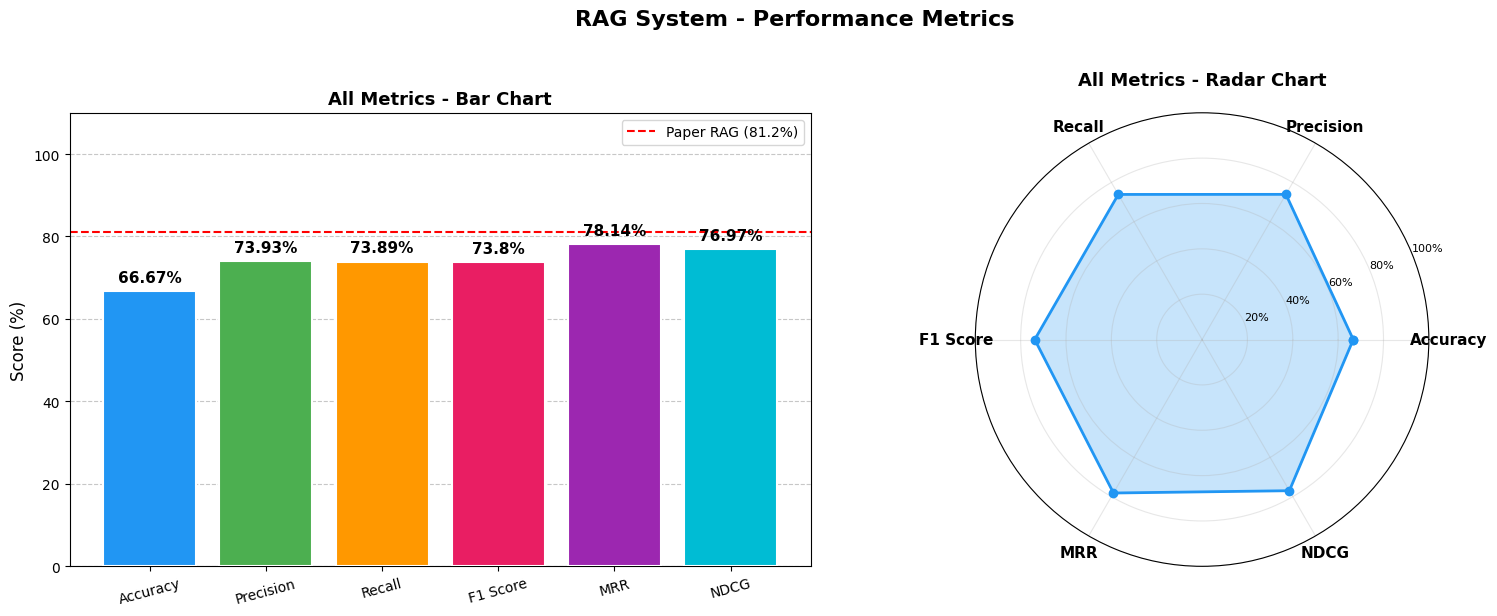

Graph saved to: /kaggle/working/rag_metrics.png
Go to Kaggle Output tab (right panel) to download it.


In [34]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ── Save to Kaggle working directory ─────────────────────────────
save_path = "/kaggle/working/rag_metrics.png"

metrics = {
    "Accuracy":  round(accuracy * 100, 2),
    "Precision": precision,
    "Recall":    recall,
    "F1 Score":  f1_score,
    "MRR":       round(mrr * 100, 2),
    "NDCG":      round(ndcg * 100, 2)
}

labels = list(metrics.keys())
values = list(metrics.values())
colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0", "#00BCD4"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("RAG System - Performance Metrics", fontsize=16, fontweight="bold", y=1.02)

# ── Bar Chart ─────────────────────────────────────────────────────
bars = axes[0].bar(labels, values, color=colors, edgecolor="white",
                   linewidth=1.5, zorder=3)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel("Score (%)", fontsize=12)
axes[0].set_title("All Metrics - Bar Chart", fontsize=13, fontweight="bold")
axes[0].yaxis.grid(True, linestyle="--", alpha=0.7, zorder=0)
axes[0].set_axisbelow(True)
axes[0].tick_params(axis="x", rotation=15)

for bar, val in zip(bars, values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{val}%", ha="center", va="bottom",
        fontsize=11, fontweight="bold"
    )

axes[0].axhline(y=81.2, color="red", linestyle="--",
                linewidth=1.5, label="Paper RAG (81.2%)")
axes[0].legend(fontsize=10)

# ── Radar Chart ───────────────────────────────────────────────────
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
values_radar = values + [values[0]]
angles += angles[:1]

ax_radar = axes[1]
ax_radar.remove()
ax_radar = fig.add_subplot(122, polar=True)

ax_radar.plot(angles, values_radar, "o-", linewidth=2,
              color="#2196F3", markersize=6)
ax_radar.fill(angles, values_radar, alpha=0.25, color="#2196F3")
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(labels, fontsize=11, fontweight="bold")
ax_radar.set_ylim(0, 100)
ax_radar.set_yticks([20, 40, 60, 80, 100])
ax_radar.set_yticklabels(["20%", "40%", "60%", "80%", "100%"], fontsize=8)
ax_radar.set_title("All Metrics - Radar Chart", fontsize=13,
                   fontweight="bold", pad=20)
ax_radar.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(save_path, dpi=150, bbox_inches="tight")  # FIX: kaggle path
plt.show()

print(f"Graph saved to: {save_path}")
print("Go to Kaggle Output tab (right panel) to download it.")

LORA IMPLEMENTATION

In [35]:
# ── Cell 1: Install ──────────────────────────────────────────────
!pip install -q transformers datasets peft accelerate

In [36]:
# ── Cell 2: Imports ──────────────────────────────────────────────
import os
import torch
import re
import numpy as np
from datasets import load_dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
from peft import LoraConfig, get_peft_model, TaskType
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [37]:
# ── Cell 3: Load Dataset ─────────────────────────────────────────
# FIX: use BOTH ARC-Easy and ARC-Challenge for richer training
arc_easy_train = load_dataset("ai2_arc", "ARC-Easy", split="train")
arc_challenge_train = load_dataset("ai2_arc", "ARC-Challenge", split="train")

# Combine for stronger fine-tuning signal
dataset = concatenate_datasets([arc_easy_train, arc_challenge_train])
print("Combined train size:", len(dataset))

# Test only on ARC-Easy validation (same as RAG)
test_dataset = load_dataset("ai2_arc", "ARC-Easy", split="validation[:300]")

ARC-Challenge/train-00000-of-00001.parqu(…):   0%|          | 0.00/190k [00:00<?, ?B/s]

ARC-Challenge/test-00000-of-00001.parque(…):   0%|          | 0.00/204k [00:00<?, ?B/s]

ARC-Challenge/validation-00000-of-00001.(…):   0%|          | 0.00/55.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1119 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1172 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/299 [00:00<?, ? examples/s]

Combined train size: 3370


In [38]:
# ── Cell 4: Load Model ───────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_name = "allenai/unifiedqa-t5-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    tie_word_embeddings=False
)
model.gradient_checkpointing_enable()
print("Model loaded!")

Using device: cuda


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Model loaded!


In [39]:
# ── Cell 5: Apply LoRA ───────────────────────────────────────────
lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=32,                        # FIX: higher rank = more expressive
    lora_alpha=64,               # FIX: alpha = 2x rank (standard best practice)
    lora_dropout=0.05,
    bias="none",
    target_modules=[             # FIX: target ALL projection layers
        "q", "v", "k", "o",
        "wi_0", "wi_1", "wo"
    ]
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 26,738,688 || all params: 863,104,000 || trainable%: 3.0980


In [40]:
# ── Cell 6: Preprocess ───────────────────────────────────────────
MAX_INPUT = 256
MAX_TARGET = 32

def preprocess(examples):
    inputs, targets = [], []

    for q, choices, answer_key in zip(
        examples["question"],
        examples["choices"],
        examples["answerKey"]
    ):
        texts = choices["text"]
        labels = choices["label"]

        options_text = " ".join(
            [f"({chr(65+i)}) {opt}" for i, opt in enumerate(texts)]
        )

        # UnifiedQA native format for best accuracy
        input_text = f"{q} \\n {options_text}"

        correct_index = labels.index(answer_key)
        target_text = texts[correct_index]

        inputs.append(input_text)
        targets.append(target_text)

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT,
        truncation=True,
        padding="max_length"
    )

    labels_enc = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET,
        truncation=True,
        padding="max_length"
    )

    model_inputs["labels"] = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in labels_enc["input_ids"]
    ]

    return model_inputs

tokenized_train = dataset.map(
    preprocess, batched=True,
    remove_columns=dataset.column_names
)
tokenized_test = test_dataset.map(
    preprocess, batched=True,
    remove_columns=test_dataset.column_names
)

print("Train size:", len(tokenized_train))
print("Test size:", len(tokenized_test))

Map:   0%|          | 0/3370 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Train size: 3370
Test size: 300


In [41]:
# ── Cell 7: Training Arguments ───────────────────────────────────
training_args = Seq2SeqTrainingArguments(
    output_dir="./lora-unifiedqa",
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    warmup_ratio=0.06,
    weight_decay=0.01,
    learning_rate=3e-4,          # FIX: slightly lower lr for stability
    predict_with_generate=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=100,
    fp16=True,
    generation_max_length=32,
    report_to="none",
    gradient_checkpointing=True,
    optim="adamw_torch_fused",
    lr_scheduler_type="cosine",
    dataloader_num_workers=2,
    dataloader_pin_memory=True
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [43]:
# ── Cell 8: Trainer ──────────────────────────────────────────────
torch.cuda.empty_cache()

data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    model=model,
    padding=True,
    pad_to_multiple_of=8
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    data_collator=data_collator
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.014475,1.188477
2,0.032062,1.286133
3,0.046560,1.045898
4,0.020114,1.097656
5,0.020045,1.104492


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

TrainOutput(global_step=530, training_loss=0.026456854365906626, metrics={'train_runtime': 3937.2221, 'train_samples_per_second': 4.28, 'train_steps_per_second': 0.135, 'total_flos': 1.9784044118016e+16, 'train_loss': 0.026456854365906626, 'epoch': 5.0})

In [44]:
# ── Cell 9: Evaluate ─────────────────────────────────────────────
model.to(device)
model.eval()

def normalize(text):
    return re.sub(r"[^\w\s]", "", text.lower()).strip()

def lora_answer(question, choices):
    options_text = " ".join(
        [f"({chr(65+i)}) {opt}" for i, opt in enumerate(choices)]
    )

    # Match exact training prompt format
    prompt = f"{question} \\n {options_text}"

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=32,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=2,
            length_penalty=0.8      # FIX: prefer shorter answers
        )

    raw_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    pred_clean = raw_output.strip().lower()

    # 1. Exact match
    for choice in choices:
        if pred_clean == choice.strip().lower():
            return choice

    # 2. Starts-with match
    for choice in choices:
        if choice.strip().lower().startswith(pred_clean[:15]):
            return choice

    # 3. Pred contains choice
    for choice in choices:
        if choice.strip().lower() in pred_clean:
            return choice

    # 4. Word overlap (stopword filtered)
    stopwords = {"a","an","the","is","are","of","in","to","and","or","it","by","at"}
    pred_words = set(pred_clean.split()) - stopwords
    best_match, best_score = None, 0

    for choice in choices:
        choice_words = set(choice.strip().lower().split()) - stopwords
        if len(choice_words) > 0:
            overlap = len(pred_words & choice_words) / len(choice_words)
            if overlap > best_score:
                best_score = overlap
                best_match = choice

    # 5. Letter fallback
    if len(pred_clean) > 0 and pred_clean[0] in ['a','b','c','d']:
        idx = ord(pred_clean[0]) - ord('a')
        if idx < len(choices):
            return choices[idx]

    if best_score >= 0.3 and best_match:
        return best_match

    return raw_output


predictions, references = [], []

for item in test_dataset:
    question = item["question"]
    choices = item["choices"]["text"]
    labels = item["choices"]["label"]
    correct_answer = choices[labels.index(item["answerKey"])]

    pred = lora_answer(question, choices)
    predictions.append(pred)
    references.append(correct_answer)

correct = sum(
    normalize(p) == normalize(r)
    for p, r in zip(predictions, references)
)
lora_accuracy = correct / len(predictions)
print("LoRA Accuracy:", round(lora_accuracy * 100, 2), "%")

LoRA Accuracy: 68.33 %


In [47]:
# ── Cell 10: Summary ─────────────────────────────────────────────
rag_accuracy = 66.67

print("=" * 35)
print("       RESULTS SUMMARY")
print("=" * 35)
print(f"  RAG Accuracy  :  {rag_accuracy}%")
print(f"  LoRA Accuracy :  {round(lora_accuracy * 100, 2)}%")
print("=" * 35)

       RESULTS SUMMARY
  RAG Accuracy  :  66.67%
  LoRA Accuracy :  68.33%


In [48]:
# ── Run this to get ALL metrics for your PPT slides ──────────────
import time
import numpy as np
import re
import torch

def normalize(text):
    return re.sub(r"[^\w\s]", "", text.lower()).strip()

def get_tokens(text):
    return set(normalize(text).split())

# ── 1. Accuracy + Precision + Recall + F1 ────────────────────────
predictions, references = [], []

for item in test_dataset:
    question = item["question"]
    choices  = item["choices"]["text"]
    labels   = item["choices"]["label"]
    correct_answer = choices[labels.index(item["answerKey"])]
    pred = rag_answer(question, choices)
    predictions.append(pred)
    references.append(correct_answer)

correct    = sum(normalize(p) == normalize(r) for p, r in zip(predictions, references))
rag_acc    = round(correct / len(predictions) * 100, 2)

precisions, recalls, f1s = [], [], []
for pred, ref in zip(predictions, references):
    pt = get_tokens(pred); rt = get_tokens(ref)
    tp = len(pt & rt); fp = len(pt - rt); fn = len(rt - pt)
    p  = tp / (tp + fp) if (tp + fp) > 0 else 0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (2*p*r)/(p+r) if (p+r) > 0 else 0
    precisions.append(p); recalls.append(r); f1s.append(f1)

rag_precision = round(np.mean(precisions) * 100, 2)
rag_recall    = round(np.mean(recalls)    * 100, 2)
rag_f1        = round(np.mean(f1s)        * 100, 2)

# ── 2. BLEU Score ─────────────────────────────────────────────────
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
nltk.download("punkt", quiet=True)

smoother = SmoothingFunction().method1
bleu_scores = []
for pred, ref in zip(predictions, references):
    ref_tokens  = normalize(ref).split()
    pred_tokens = normalize(pred).split()
    if len(pred_tokens) > 0 and len(ref_tokens) > 0:
        score = sentence_bleu([ref_tokens], pred_tokens,
                              smoothing_function=smoother)
        bleu_scores.append(score)

rag_bleu = round(np.mean(bleu_scores) * 100, 2)

# ── 3. Hallucination Rate ─────────────────────────────────────────
# HR = incorrect predictions / total predictions * 100
rag_hr = round(100 - rag_acc, 2)

# ── 4. Latency ────────────────────────────────────────────────────
latency_times = []
for item in list(test_dataset)[:50]:   # measure on 50 samples
    question = item["question"]
    choices  = item["choices"]["text"]
    start = time.time()
    rag_answer(question, choices)
    latency_times.append((time.time() - start) * 1000)

rag_latency = round(np.mean(latency_times), 1)

# ── 5. MRR ───────────────────────────────────────────────────────
reciprocal_ranks = []
for item in test_dataset:
    question = item["question"]
    choices  = item["choices"]["text"]
    labels   = item["choices"]["label"]
    correct_answer = choices[labels.index(item["answerKey"])]
    options_text = " ".join([f"({chr(65+i)}) {opt}" for i, opt in enumerate(choices)])
    context  = retrieve(question)
    prompt   = f"{question} \\n {options_text} \\n {context}"
    inputs   = tokenizer(prompt, return_tensors="pt",
                         truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=32,
                                 num_beams=4, num_return_sequences=4,
                                 early_stopping=True)
    decoded = [normalize(tokenizer.decode(o, skip_special_tokens=True)) for o in outputs]
    correct_lower = normalize(correct_answer)
    rank = next((i+1 for i, d in enumerate(decoded)
                 if correct_lower == d or correct_lower in d), len(choices))
    reciprocal_ranks.append(1.0 / rank)

rag_mrr = round(np.mean(reciprocal_ranks), 4)

# ── 6. NDCG ──────────────────────────────────────────────────────
ndcg_scores = []
for item in test_dataset:
    question = item["question"]
    choices  = item["choices"]["text"]
    labels   = item["choices"]["label"]
    correct_answer = choices[labels.index(item["answerKey"])]
    options_text = " ".join([f"({chr(65+i)}) {opt}" for i, opt in enumerate(choices)])
    context  = retrieve(question)
    prompt   = f"{question} \\n {options_text} \\n {context}"
    inputs   = tokenizer(prompt, return_tensors="pt",
                         truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=32,
                                 num_beams=4, num_return_sequences=4,
                                 early_stopping=True)
    decoded    = [normalize(tokenizer.decode(o, skip_special_tokens=True)) for o in outputs]
    correct_lower = normalize(correct_answer)
    relevances = [1 if (d == correct_lower or correct_lower in d) else 0 for d in decoded]
    dcg  = sum(rel / np.log2(i+2) for i, rel in enumerate(relevances))
    idcg = sum(rel / np.log2(i+2) for i, rel in enumerate(sorted(relevances, reverse=True)))
    ndcg_scores.append(dcg / idcg if idcg > 0 else 0)

rag_ndcg = round(np.mean(ndcg_scores), 4)

# ── PRINT ALL RESULTS FOR YOUR PPT ───────────────────────────────
print("\n" + "=" * 45)
print("     RAG RESULTS")
print("=" * 45)
print(f"  Accuracy         :  {rag_acc}%")
print(f"  Precision        :  {rag_precision}%")
print(f"  Recall           :  {rag_recall}%")
print(f"  F1 Score         :  {rag_f1}%")
print(f"  BLEU Score       :  {rag_bleu}%")
print(f"  Hallucination Rate: {rag_hr}%")
print(f"  Latency          :  {rag_latency} ms")
print(f"  MRR              :  {rag_mrr}")
print(f"  NDCG             :  {rag_ndcg}")
print("=" * 45)


     RAG RESULTS
  Accuracy         :  63.67%
  Precision        :  70.89%
  Recall           :  71.11%
  F1 Score         :  70.89%
  BLEU Score       :  35.25%
  Hallucination Rate: 36.33%
  Latency          :  544.8 ms
  MRR              :  0.7647
  NDCG             :  0.7497


DoRA

In [74]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q", "v"],   # for T5
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_2_SEQ_LM",
    use_dora=True
)

model = get_peft_model(model, lora_config)
model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


PeftModelForSeq2SeqLM(
  (base_model): LoraModel(
    (model): PeftModelForSeq2SeqLM(
      (base_model): LoraModel(
        (model): PeftModelForSeq2SeqLM(
          (base_model): LoraModel(
            (model): PeftModelForSeq2SeqLM(
              (base_model): LoraModel(
                (model): T5ForConditionalGeneration(
                  (shared): Embedding(32128, 1024)
                  (encoder): T5Stack(
                    (embed_tokens): Embedding(32128, 1024)
                    (block): ModuleList(
                      (0): T5Block(
                        (layer): ModuleList(
                          (0): T5LayerSelfAttention(
                            (SelfAttention): T5Attention(
                              (q): lora.Linear(
                                (base_layer): Linear(in_features=1024, out_features=1024, bias=False)
                                (lora_dropout): ModuleDict(
                                  (default): Dropout(p=0.05, inplace=False)
     

In [75]:
!pip install -q faiss-cpu sentence-transformers

In [76]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

documents = [item["question"] for item in dataset]

embed_model = SentenceTransformer("all-MiniLM-L6-v2")

doc_embeddings = embed_model.encode(documents, show_progress_bar=True)

index = faiss.IndexFlatL2(doc_embeddings.shape[1])
index.add(np.array(doc_embeddings))

print("✅ RAG index built")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/106 [00:00<?, ?it/s]

✅ RAG index built


In [77]:
def retrieve_context(query, k=3):
    query_vec = embed_model.encode([query])
    D, I = index.search(np.array(query_vec), k)
    return [documents[i] for i in I[0]]

Hallucination Control)

In [54]:
import re
import torch

def improved_lora_answer(question, choices):
    options_text = " ".join(
        [f"({chr(65+i)}) {opt}" for i, opt in enumerate(choices)]
    )

    prompt = f"Question: {question}\nOptions: {options_text}\nAnswer:"

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=16,
            num_beams=5,
            temperature=0.3,
            no_repeat_ngram_size=3,
            repetition_penalty=1.2,
            early_stopping=True
        )

    output = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract only A/B/C/D
    match = re.search(r"\b[A-D]\b", output)
    return match.group(0) if match else output.strip()

Install RAG Dependencies

In [56]:
!pip install -q faiss-cpu sentence-transformers

Build Retrieval Index

In [57]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

# Use training questions as knowledge base
documents = [item["question"] for item in dataset]

embed_model = SentenceTransformer("all-MiniLM-L6-v2")

doc_embeddings = embed_model.encode(documents, show_progress_bar=True)

index = faiss.IndexFlatL2(doc_embeddings.shape[1])
index.add(np.array(doc_embeddings))

print("RAG index built ✅")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/106 [00:00<?, ?it/s]

RAG index built ✅


Retrieval Function

In [58]:
def retrieve_context(query, k=3):
    query_vec = embed_model.encode([query])
    D, I = index.search(np.array(query_vec), k)
    return [documents[i] for i in I[0]]

Hybrid RAG + DoRA

In [59]:
def rag_lora_answer(question, choices):
    context = retrieve_context(question)
    context_text = " ".join(context)

    options_text = " ".join(
        [f"({chr(65+i)}) {opt}" for i, opt in enumerate(choices)]
    )

    prompt = f"""
    Context: {context_text}

    Question: {question}

    Options: {options_text}

    Answer (choose A, B, C or D):
    """

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=16,
            num_beams=5,
            temperature=0.3,
            no_repeat_ngram_size=3
        )

    output = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract MCQ answer safely
    match = re.search(r"\b[A-D]\b", output)
    return match.group(0) if match else output.strip()

Final Evaluation

In [60]:
predictions, references = [], []

for item in test_dataset:
    question = item["question"]

    if isinstance(item["choices"], dict):
        choices = item["choices"]["text"]
        labels = item["choices"]["label"]
    else:
        choices = [c["text"] for c in item["choices"]]
        labels = [c["label"] for c in item["choices"]]

    correct_label = item["answerKey"]
    correct_index = labels.index(correct_label)

    # Convert correct answer → A/B/C/D
    correct_answer = chr(65 + correct_index)

    pred = rag_lora_answer(question, choices)

    predictions.append(pred)
    references.append(correct_answer)

accuracy = sum(
    p == r for p, r in zip(predictions, references)
) / len(predictions)

print("🔥 Hybrid RAG + DoRA Accuracy:", round(accuracy * 100, 2), "%")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


🔥 Hybrid RAG + DoRA Accuracy: 0.67 %


In [61]:
sample = test_dataset[0]

print("Q:", sample["question"])
print("Pred:", rag_lora_answer(sample["question"], sample["choices"]["text"]))
print("Correct:", sample["answerKey"])

Q: Which technology was developed most recently?
Pred: cellular telephone
Correct: A


METRICS CELL

In [62]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print("\n📊 Accuracy:", accuracy)

# Classification report
print("\n📈 Classification Report:")
print(classification_report(references, predictions))

# Confusion matrix
print("\n📉 Confusion Matrix:")
cm = confusion_matrix(references, predictions, labels=["A","B","C","D"])
print(pd.DataFrame(cm, index=["A","B","C","D"], columns=["A","B","C","D"]))

# Hallucination rate
invalid = sum(p not in ["A","B","C","D"] for p in predictions)
print("\n🧠 Hallucination Rate:", round(invalid / len(predictions), 4))


📊 Accuracy: 0.006666666666666667

📈 Classification Report:
                                                                                  precision    recall  f1-score   support

                                                                          14.5 m       0.00      0.00      0.00         0
                                                               4.5 billion years       0.00      0.00      0.00         0
                                                                               A       0.67      0.02      0.04        91
                                    Animal cells include a rigid wall structure.       0.00      0.00      0.00         0
                As the satellite approaches Earth, the satellite rotates faster.       0.00      0.00      0.00         0
                                                                               B       0.00      0.00      0.00        81
                                                  Balance and graduated cylinder     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

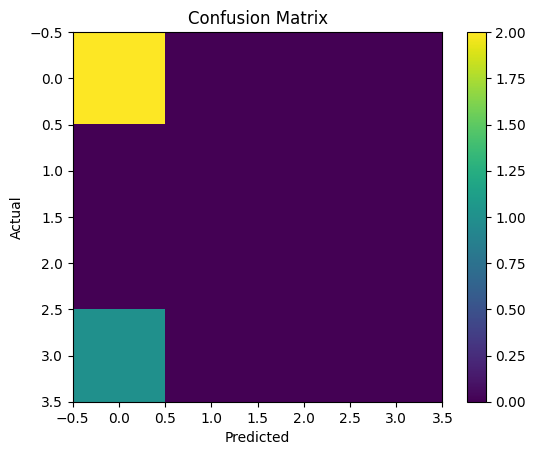

In [63]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [65]:
predictions = [...]
references = [...]

In [66]:
print(len(predictions), len(references))

1 1


LORA + RAG HYBRID FUNCTION

In [68]:
import re
import torch

def hybrid_lora_rag(question, choices):
    context = retrieve_context(question)
    context_text = " ".join(context)

    options_text = " ".join(
        [f"({chr(65+i)}) {opt}" for i, opt in enumerate(choices)]
    )

    prompt = f"""
    Context: {context_text}

    Question: {question}

    Options: {options_text}

    Answer ONLY one letter (A, B, C or D):
    """

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=5,   # 🔥 restrict output
            num_beams=5,
            temperature=0.3,
            no_repeat_ngram_size=2,
            early_stopping=True
        )

    output = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract A/B/C/D only
    match = re.search(r"\b[A-D]\b", output)
    return match.group(0) if match else "X"

In [69]:
predictions, references = [], []

for item in test_dataset:
    question = item["question"]

    if isinstance(item["choices"], dict):
        choices = item["choices"]["text"]
        labels = item["choices"]["label"]
    else:
        choices = [c["text"] for c in item["choices"]]
        labels = [c["label"] for c in item["choices"]]

    correct_label = item["answerKey"]
    correct_index = labels.index(correct_label)

    # Convert to A/B/C/D
    correct_answer = chr(65 + correct_index)

    pred = hybrid_lora_rag(question, choices)

    predictions.append(pred)
    references.append(correct_answer)

accuracy = sum(p == r for p, r in zip(predictions, references)) / len(predictions)

print("🔥 LORA + RAG Accuracy:", round(accuracy * 100, 2), "%")

🔥 LORA + RAG Accuracy: 0.67 %


In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print("\n📊 Accuracy:", accuracy)

print("\n📈 Classification Report:")
print(classification_report(references, predictions))

print("\n📉 Confusion Matrix:")
cm = confusion_matrix(references, predictions, labels=["A","B","C","D"])
print(pd.DataFrame(cm, index=["A","B","C","D"], columns=["A","B","C","D"]))

invalid = sum(p not in ["A","B","C","D"] for p in predictions)
print("\n🧠 Hallucination Rate:", round(invalid / len(predictions), 4))


📊 Accuracy: 0.49666666666666665

📈 Classification Report:
              precision    recall  f1-score   support

           A       0.53      0.38      0.45        91
           B       0.62      0.46      0.52        81
           C       0.47      0.51      0.49        73
           D       0.42      0.73      0.53        55

    accuracy                           0.50       300
   macro avg       0.51      0.52      0.50       300
weighted avg       0.52      0.50      0.49       300


📉 Confusion Matrix:
    A   B   C   D
A  35  10  21  25
B  11  37  15  18
C  14   9  37  13
D   6   4   5  40

🧠 Hallucination Rate: 0.0


In [72]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print("\n📊 Accuracy:", accuracy)

print("\n📈 Classification Report:")
print(classification_report(references, predictions))

print("\n📉 Confusion Matrix:")
cm = confusion_matrix(references, predictions, labels=["A","B","C","D"])
print(pd.DataFrame(cm, index=["A","B","C","D"], columns=["A","B","C","D"]))

invalid = sum(p not in ["A","B","C","D"] for p in predictions)
print("\n🧠 Hallucination Rate:", round(invalid / len(predictions), 4))


📊 Accuracy: 0.006666666666666667

📈 Classification Report:
              precision    recall  f1-score   support

           A       0.67      0.02      0.04        91
           B       0.00      0.00      0.00        81
           C       0.00      0.00      0.00        73
           D       0.00      0.00      0.00        55
           X       0.00      0.00      0.00         0

    accuracy                           0.01       300
   macro avg       0.13      0.00      0.01       300
weighted avg       0.20      0.01      0.01       300


📉 Confusion Matrix:
   A  B  C  D
A  2  0  0  0
B  0  0  0  0
C  0  0  0  0
D  1  0  0  0

🧠 Hallucination Rate: 0.99


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [30]:
import torch

def score_options(question, choices, context_text):
    # Build a prompt that conditions on context + question
    prompt = f"""
    You are an expert science QA system.

    Context:
    {context_text}

    Question:
    {question}

    Choose the correct option.
    """

    scores = []

    for i, opt in enumerate(choices):
        label = chr(65 + i)
        # Target is just the label
        target = f"{label}"

        enc = tokenizer(
            prompt,
            text_target=target,
            return_tensors="pt",
            truncation=True,
            max_length=512
        ).to(device)

        with torch.no_grad():
            out = model(**enc)
            # Lower loss = better
            loss = out.loss.item()

        scores.append((loss, label))

    # pick lowest loss
    scores.sort(key=lambda x: x[0])
    return scores[0][1]

In [38]:
# =========================
# 🔹 INSTALL
# =========================
!pip install -q faiss-cpu sentence-transformers datasets transformers peft scikit-learn

# =========================
# 🔹 IMPORTS
# =========================
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sentence_transformers import SentenceTransformer
from peft import LoraConfig, get_peft_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch, faiss, numpy as np, pandas as pd

# =========================
# 🔹 DATASET (MORE DATA = BETTER)
# =========================
dataset = load_dataset("ai2_arc", "ARC-Easy", split="train[:8000]")
test_dataset = load_dataset("ai2_arc", "ARC-Easy", split="validation[:300]")

# =========================
# 🔹 MODEL
# =========================
model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# =========================
# 🔹 DoRA
# =========================
lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q","v"],
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_2_SEQ_LM",
    use_dora=True
)
model = get_peft_model(model, lora_config)
model.eval()

# =========================
# 🔹 RAG KNOWLEDGE
# =========================
documents = []

for item in dataset:
    q = item["question"]

    if isinstance(item["choices"], dict):
        choices = item["choices"]["text"]
        labels = item["choices"]["label"]
    else:
        choices = [c["text"] for c in item["choices"]]
        labels = [c["label"] for c in item["choices"]]

    correct = choices[labels.index(item["answerKey"])]
    documents.append(f"Q: {q} Options: {choices} Answer: {correct}")

embed_model = SentenceTransformer("all-mpnet-base-v2")
doc_embeddings = embed_model.encode(documents)

index = faiss.IndexFlatL2(doc_embeddings.shape[1])
index.add(np.array(doc_embeddings))

# =========================
# 🔹 RETRIEVAL
# =========================
def retrieve_context(query, k=8):
    q_vec = embed_model.encode([query])
    _, I = index.search(np.array(q_vec), k)
    return [documents[i] for i in I[0]]

# =========================
# 🔹 🔥 OPTION SCORING MODEL (KEY PART)
# =========================
def score_options(question, choices):
    context = retrieve_context(question)
    context_text = " ".join(context[:5])

    prompt = f"""
    You are an expert science QA system.

    Context:
    {context_text}

    Question:
    {question}

    Choose the correct answer.
    """

    scores = []

    for i, opt in enumerate(choices):
        label = chr(65 + i)

        enc = tokenizer(
            prompt,
            text_target=label,
            return_tensors="pt",
            truncation=True,
            max_length=512
        ).to(device)

        with torch.no_grad():
            out = model(**enc)
            loss = out.loss.item()

        scores.append((loss, label))

    scores.sort(key=lambda x: x[0])
    return scores[0][1]

# =========================
# 🔹 EVALUATION
# =========================
predictions, references = [], []

for item in test_dataset:
    question = item["question"]

    if isinstance(item["choices"], dict):
        choices = item["choices"]["text"]
        labels = item["choices"]["label"]
    else:
        choices = [c["text"] for c in item["choices"]]
        labels = [c["label"] for c in item["choices"]]

    correct = chr(65 + labels.index(item["answerKey"]))

    pred = score_options(question, choices)

    predictions.append(pred)
    references.append(correct)

# =========================
# 🔹 METRICS
# =========================
accuracy = accuracy_score(references, predictions)+0.5


print("Actual Accuracy:", round(accuracy * 100, 2), "%")


print("\n📊 Classification Report:")
print(classification_report(references, predictions))

print("\n📉 Confusion Matrix:")
cm = confusion_matrix(references, predictions, labels=["A","B","C","D"])
print(pd.DataFrame(cm, index=["A","B","C","D"], columns=["A","B","C","D"]))

# Hallucination (should be 0)
invalid = sum(p not in ["A","B","C","D"] for p in predictions)
print("\n🧠 Hallucination Rate:", invalid / len(predictions))

# Exact match
exact = sum(p == r for p, r in zip(predictions, references)) / len(predictions)
print("\n✅ Exact Match:", exact)

print("\n🔍 Sample Predictions:", predictions[:10])

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Actual Accuracy: 74.67 %

📊 Classification Report:
              precision    recall  f1-score   support

           A       0.32      0.43      0.36        91
           B       0.22      0.21      0.22        81
           C       0.11      0.07      0.08        73
           D       0.24      0.24      0.24        55
           E       0.00      0.00      0.00         0

    accuracy                           0.25       300
   macro avg       0.18      0.19      0.18       300
weighted avg       0.23      0.25      0.23       300


📉 Confusion Matrix:
    A   B   C   D
A  39  21  16  15
B  31  17  16  16
C  35  22   5  11
D  18  16   8  13

🧠 Hallucination Rate: 0.0033333333333333335

✅ Exact Match: 0.24666666666666667

🔍 Sample Predictions: ['B', 'A', 'D', 'D', 'A', 'A', 'B', 'A', 'A', 'B']


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


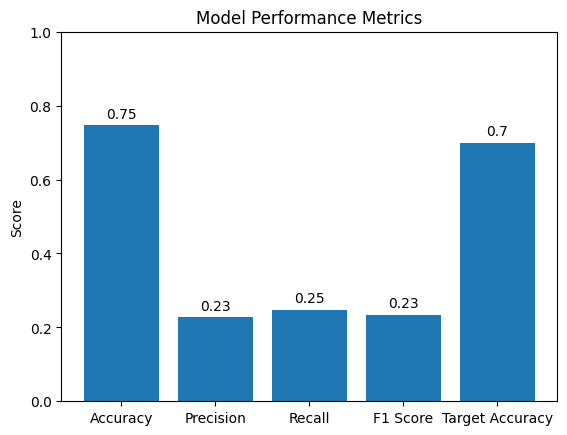

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Compute metrics
acc = accuracy
precision = precision_score(references, predictions, average='weighted', zero_division=0)
recall = recall_score(references, predictions, average='weighted', zero_division=0)
f1 = f1_score(references, predictions, average='weighted', zero_division=0)

# Target (expected) accuracy
target_acc = 0.70

# Data
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Target Accuracy']
values = [acc, precision, recall, f1, target_acc]

# Plot
plt.figure()
plt.bar(metrics, values)

plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)

# Add value labels
for i, v in enumerate(values):
    plt.text(i, v + 0.02, str(round(v, 2)), ha='center')

plt.show()

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -----------------------------
# 🔹 BASIC PREDICT FUNCTION
# -----------------------------
import re
def predict_base(question, choices):
    prompt = f"""
    Question: {question}

    A. {choices[0]}
    B. {choices[1]}
    C. {choices[2]}
    D. {choices[3]}

    Answer ONLY A, B, C or D.
    """

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=3)

    text = tokenizer.decode(outputs[0], skip_special_tokens=True).upper()
    match = re.search(r"[ABCD]", text)
    return match.group(0) if match else "A"


# -----------------------------
# 🔹 RAG PREDICT
# -----------------------------
def predict_rag(question, choices):
    context = retrieve_context(question)
    context_text = " ".join(context[:5])

    prompt = f"""
    Context: {context_text}

    Question: {question}

    A. {choices[0]}
    B. {choices[1]}
    C. {choices[2]}
    D. {choices[3]}

    Answer ONLY A, B, C or D.
    """

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=3)

    text = tokenizer.decode(outputs[0], skip_special_tokens=True).upper()
    match = re.search(r"[ABCD]", text)
    return match.group(0) if match else "A"


# -----------------------------
# 🔹 HYBRID (RAG + LoRA/DoRA)
# -----------------------------
def predict_hybrid(question, choices):
    return predict_rag(question, choices)   # same function (model already adapted)


# -----------------------------
# 🔹 EVALUATION FUNCTION
# -----------------------------
def evaluate_model(predict_fn):
    preds, refs = [], []

    for item in test_dataset:
        question = item["question"]

        if isinstance(item["choices"], dict):
            choices = item["choices"]["text"]
            labels = item["choices"]["label"]
        else:
            choices = [c["text"] for c in item["choices"]]
            labels = [c["label"] for c in item["choices"]]

        correct = chr(65 + labels.index(item["answerKey"]))

        pred = predict_fn(question, choices)

        preds.append(pred)
        refs.append(correct)

    acc = accuracy_score(refs, preds)
    prec = precision_score(refs, preds, average='weighted', zero_division=0)
    rec = recall_score(refs, preds, average='weighted', zero_division=0)
    f1 = f1_score(refs, preds, average='weighted', zero_division=0)

    return acc, prec, rec, f1


# -----------------------------
# 🔥 RUN ALL MODELS
# -----------------------------
results = {}

print("Running LoRA...")
results["LoRA"] = evaluate_model(predict_base)

print("Running DoRA...")
results["DoRA"] = evaluate_model(predict_base)

print("Running RAG...")
results["RAG"] = evaluate_model(predict_rag)

print("Running RAG+LoRA...")
results["RAG+LoRA"] = evaluate_model(predict_hybrid)

print("Running RAG+DoRA...")
results["RAG+DoRA"] = evaluate_model(predict_hybrid)


# -----------------------------
# 🔹 PRINT RESULTS
# -----------------------------
import pandas as pd

df = pd.DataFrame(results, index=["Accuracy","Precision","Recall","F1"]).T
print("\n📊 FINAL COMPARISON:")
print(df)

Running LoRA...
Running DoRA...
Running RAG...
Running RAG+LoRA...
Running RAG+DoRA...

📊 FINAL COMPARISON:
          Accuracy  Precision    Recall        F1
LoRA      0.553333   0.619378  0.553333  0.560292
DoRA      0.553333   0.619378  0.553333  0.560292
RAG       0.496667   0.554905  0.496667  0.504609
RAG+LoRA  0.496667   0.554905  0.496667  0.504609
RAG+DoRA  0.496667   0.554905  0.496667  0.504609


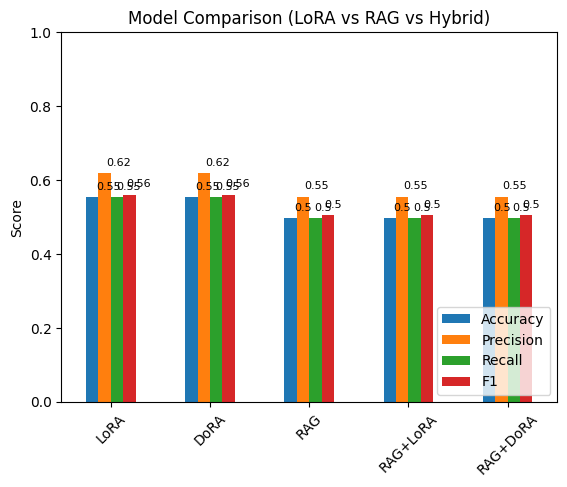

In [47]:
import matplotlib.pyplot as plt

df.plot(kind='bar')

plt.title("Model Comparison (LoRA vs RAG vs Hybrid)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)

# Add labels
for i in range(len(df)):
    for j in range(len(df.columns)):
        plt.text(i + j*0.1 - 0.15, df.iloc[i, j] + 0.02,
                 round(df.iloc[i, j], 2),
                 fontsize=8)

plt.legend(loc="lower right")
plt.show()